# XGBoost con `procesed.csv`

Flujo: carga de datos, limpieza básica, entrenamiento, evaluación, análisis de importancia de variables y guardado del modelo.

## Paso a paso del proceso
1. Preparacion del entorno e importacion de librerias.
2. Carga del dataset data/procesed.csv.
3. Definicion de la variable objetivo (is_canceled).
4. Revision rapida de nulos y duplicados.
5. Preprocesado con ColumnTransformer.
6. Entrenamiento con XGBClassifier.
7. Evaluacion con F1, Recall, Precision, Accuracy y ROC-AUC.
8. Interpretacion con importancia de variables.
9. Guardado y reutilizacion del modelo en models/test/artifacts/xgboost.pkl.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError('Falta xgboost. Instálalo en tu entorno con: pip install xgboost') from exc

RANDOM_STATE = 42
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
start = Path.cwd().resolve()
project_root = None
for p in [start, *start.parents]:
    if (p / 'pyproject.toml').exists() or (p / 'requirements.txt').exists():
        project_root = p
        break
if project_root is None:
    project_root = start

csv_path = project_root / 'data' / 'procesed.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontró el archivo esperado: {csv_path}')

df = pd.read_csv(csv_path)
print(f'Archivo: {csv_path}')
print('Shape:', df.shape)
display(df.head())
df.info()

Archivo: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-limpio\data\procesed.csv
Shape: (86634, 26)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_children,week_sin,week_cos
0,Resort Hotel,0,7,2015,July,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,No Deposit,Transient,75.0,0,0,0,-0.120537,-0.992709
1,Resort Hotel,0,13,2015,July,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,No Deposit,Transient,75.0,0,0,0,-0.120537,-0.992709
2,Resort Hotel,0,14,2015,July,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,98.0,0,1,0,-0.120537,-0.992709
3,Resort Hotel,0,0,2015,July,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,107.0,0,0,0,-0.120537,-0.992709
4,Resort Hotel,0,9,2015,July,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,103.0,0,1,0,-0.120537,-0.992709


<class 'pandas.DataFrame'>
RangeIndex: 86634 entries, 0 to 86633
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86634 non-null  str    
 1   is_canceled                     86634 non-null  int64  
 2   lead_time                       86634 non-null  int64  
 3   arrival_date_year               86634 non-null  int64  
 4   arrival_date_month              86634 non-null  str    
 5   stays_in_weekend_nights         86634 non-null  int64  
 6   stays_in_week_nights            86634 non-null  int64  
 7   adults                          86634 non-null  int64  
 8   children                        86634 non-null  float64
 9   babies                          86634 non-null  int64  
 10  meal                            86634 non-null  str    
 11  country                         86634 non-null  str    
 12  market_segment                  86634 non-n

In [3]:
TARGET = 'is_canceled'
if TARGET not in df.columns:
    raise ValueError(f'No existe la columna objetivo: {TARGET}')

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print('Variable objetivo:', TARGET)
print('Distribucion del target:')
display(y.value_counts(normalize=True).rename('ratio'))
display(df.isna().sum().sort_values(ascending=False).head(10))
print('Duplicados:', df.duplicated().sum())

Variable objetivo: is_canceled
Distribucion del target:


is_canceled
0    0.72318
1    0.27682
Name: ratio, dtype: float64

hotel                      0
is_canceled                0
lead_time                  0
arrival_date_year          0
arrival_date_month         0
stays_in_weekend_nights    0
stays_in_week_nights       0
adults                     0
children                   0
babies                     0
dtype: int64

Duplicados:

 2200


In [4]:
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

def metrics(y_true, y_pred, y_proba=None, label=''):
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    print(f'[{label}] F1={f1:.4f} | Recall={rec:.4f} | Precision={prec:.4f} | Accuracy={acc:.4f} | ROC-AUC={auc:.4f}')

metrics(y_train, y_pred_train, model.predict_proba(X_train)[:, 1], 'Train')
metrics(y_test, y_pred_test, y_proba_test, 'Test')

[Train] F1=0.6998 | Recall=0.6474 | Precision=0.7613 | Accuracy=0.8462 | ROC-AUC=0.9130
[Test] F1=0.6746 | Recall=0.6239 | Precision=0.7344 | Accuracy=0.8334 | ROC-AUC=0.8966


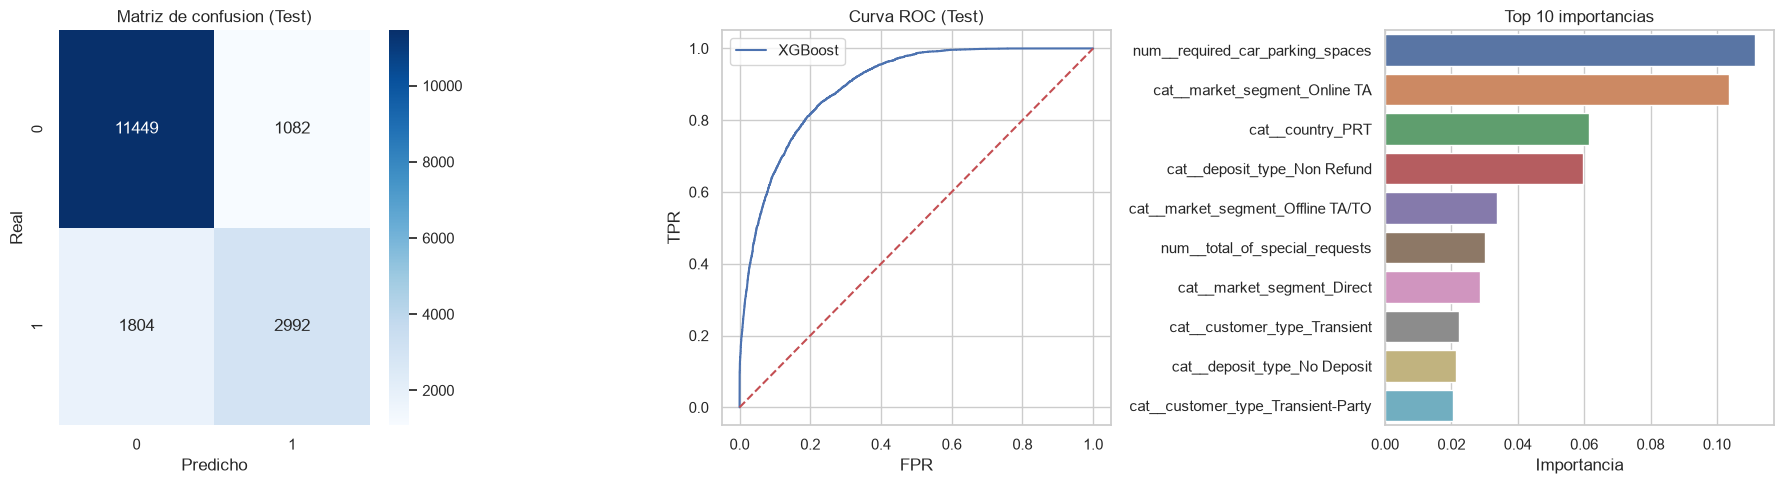

,feature,importance
11,num__required_car_parking_spaces,0.111633
210,cat__market_segment_Online TA,0.103705
162,cat__country_PRT,0.061338
225,cat__deposit_type_Non Refund,0.059521
209,cat__market_segment_Offline TA/TO,0.033726
12,num__total_of_special_requests,0.030175
207,cat__market_segment_Direct,0.028744
229,cat__customer_type_Transient,0.022359
224,cat__deposit_type_No Deposit,0.021396
230,cat__customer_type_Transient-Party,0.020536


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusion (Test)')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, label='XGBoost')
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('Curva ROC (Test)')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

feature_names = model.named_steps['preprocess'].get_feature_names_out()
importances = model.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
sns.barplot(data=importance_df.head(10), y='feature', x='importance', ax=axes[2], hue='feature', legend=False)
axes[2].set_title('Top 10 importancias')
axes[2].set_xlabel('Importancia')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()
display(importance_df.head(20))

In [6]:
out_dir = project_root / 'models' / 'test' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)
model_path = out_dir / 'xgboost.pkl'
joblib.dump(model, model_path)
print(f'Modelo guardado en: {model_path}')

loaded_model = joblib.load(model_path)
sample_proba = loaded_model.predict_proba(X_test.head(5))[:, 1]
sample_pred = loaded_model.predict(X_test.head(5))
display(pd.DataFrame({'real': y_test.head(5).values, 'predicho': sample_pred, 'proba_cancelacion': sample_proba}))

Modelo guardado en: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\PRACTICA-MACHINE-LEARNING-limpio\models\test\artifacts\xgboost.pkl


,real,predicho,proba_cancelacion
0,1,1,0.742948
1,0,0,0.221974
2,0,0,0.110521
3,0,0,0.013521
4,1,1,0.716628
